In [ ]:
import os
import cv2
import numpy as np
import kagglehub
import keras
import pandas as pd
import tensorflow.data as tfd
import tensorflow.image as tfi
import tensorflow as tf

import plotly.express as px
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2, MobileNetV2, DenseNet121
from IPython.display import clear_output as cls
from plotly.offline import init_notebook_mode
from sklearn.model_selection import train_test_split
init_notebook_mode(connected=True)

# Data Processing

In [ ]:
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

path = 'C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/'
print("Path to dataset files:", path)

Path to dataset files: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/


In [9]:
train_csv = pd.read_csv(path + "train.csv")
train_csv["file_name"] = path + train_csv["file_name"]

print(f"Number of dataset samples: {train_csv.shape[0]}")

Number of dataset samples: 79950


In [10]:
train_csv = train_csv.drop(columns='Unnamed: 0', axis=1)
train_csv.head()

,file_name,label
0,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1
1,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,0
2,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1
3,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,0
4,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1


In [11]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79950 entries, 0 to 79949
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  79950 non-null  object
 1   label      79950 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.2+ MB


In [12]:
class_distribution = train_csv['label'].value_counts()
class_distribution

label
1    39975
0    39975
Name: count, dtype: int64

the dataset is balanced between human images (0) and AI images (1), each with 39975 images each class.

In [13]:
for i in range(5):
    image_path = os.path.join(path, train_csv.file_name[i])

    try:
        image = plt.imread(image_path)
        shape = image.shape

        print(f"Image {i+1}: {train_csv.file_name[i]}")
        print(f" - Shape: {shape}")
        print(f" - Image Path: {image_path}\n")

    except FileNotFoundError:
        print(f"⚠ Warning: File not found - {image_path}")

    except Exception as e:
        print(f"⚠ Error loading image {train_csv.file_name[i]}: {e}")

Image 1: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/a6dcb93f596a43249135678dfcfc17ea.jpg
 - Shape: (768, 512, 3)
 - Image Path: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/a6dcb93f596a43249135678dfcfc17ea.jpg

Image 2: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/041be3153810433ab146bc97d5af505c.jpg
 - Shape: (768, 512, 3)
 - Image Path: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/041be3153810433ab146bc97d5af505c.jpg

Image 3: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg
 - Shape: (512, 768, 3)
 - Image Path: C:/Users/Mercury/.cache/kagglehub/datasets/alessandrasala79/ai-vs-human-generated-dataset/train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg

Image 4: C:/Users/Mercury

In [14]:
train_csv["label"] = train_csv["label"].astype(str)
train_csv.head()

,file_name,label
0,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1
1,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,0
2,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1
3,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,0
4,C:/Users/Mercury/.cache/kagglehub/datasets/ale...,1


In [10]:
train_df, temp_df = train_test_split(
    train_csv,
    test_size=0.2,
    random_state=42,
    stratify=train_csv['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Training Data   : {len(train_df)} ({len(train_df)/len(train_csv):.1%})")
print(f"Validation Data : {len(val_df)} ({len(val_df)/len(train_csv):.1%})")
print(f"Testing Data    : {len(test_df)} ({len(test_df)/len(train_csv):.1%})")

Training Data   : 63960 (80.0%)
Validation Data : 7995 (10.0%)
Testing Data    : 7995 (10.0%)


In [11]:
def preprocess_and_darken(image):
    image = image.astype('float32')
    image /= 255.0 # normalize the dataset
    darkening_factor = 0.6
    darkened_image = image * darkening_factor
    return darkened_image

data_generator = ImageDataGenerator(preprocessing_function=preprocess_and_darken)

In [12]:
target_size = (512, 512)
batch_size = 32

train_generator = data_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="file_name",
    y_col="label",
    target_size=target_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

valid_generator = data_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col="file_name",
    y_col="label",
    target_size=target_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_generator = data_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="file_name",
    y_col="label",
    target_size=target_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 63960 validated image filenames belonging to 2 classes.
Found 7995 validated image filenames belonging to 2 classes.
Found 7995 validated image filenames belonging to 2 classes.


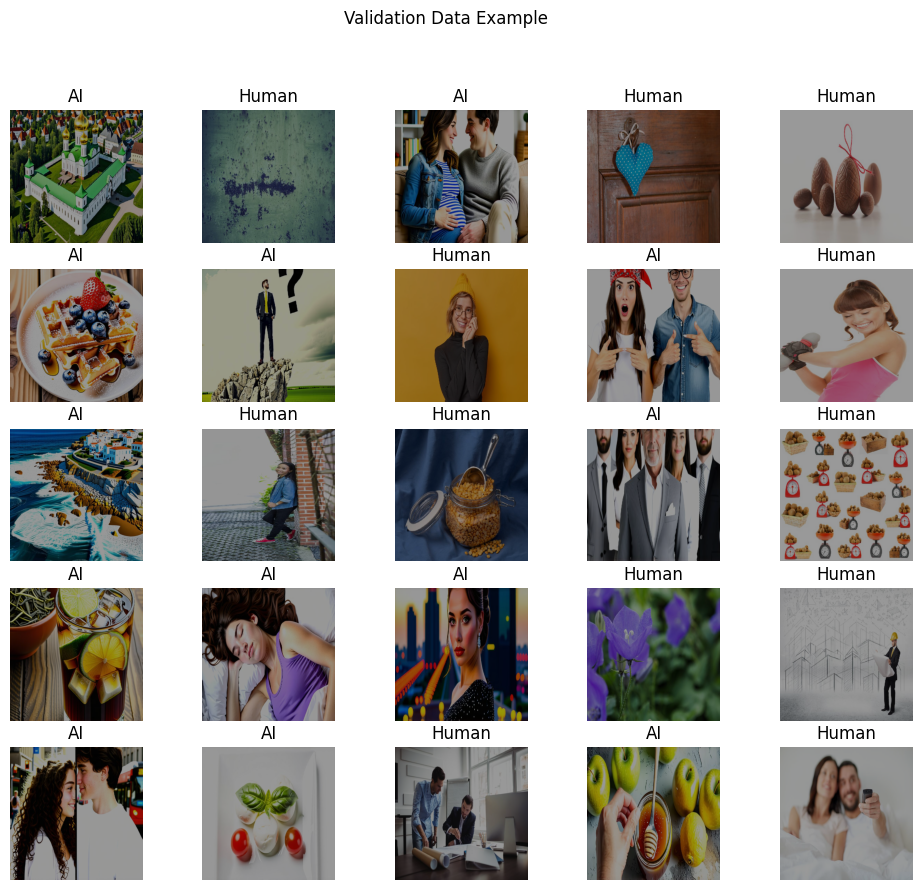

In [13]:
def show_images(data, name, n_rows=5, n_cols=5, figsize=(12, 10)):

    images, labels = next(iter(data))

    plt.figure(figsize=figsize)

    n_image = 0

    for i in range(n_rows):
        for j in range(n_cols):
            if n_image < len(images):
                plt.subplot(n_rows, n_cols, n_image + 1)
                plt.imshow(images[n_image])
                plt.axis('off')
                plt.title("AI" if labels[n_image] == 1.0 else "Human")
                n_image += 1

    plt.suptitle(f'{name} Data Example')
    plt.show()

show_images(valid_generator, 'Validation')

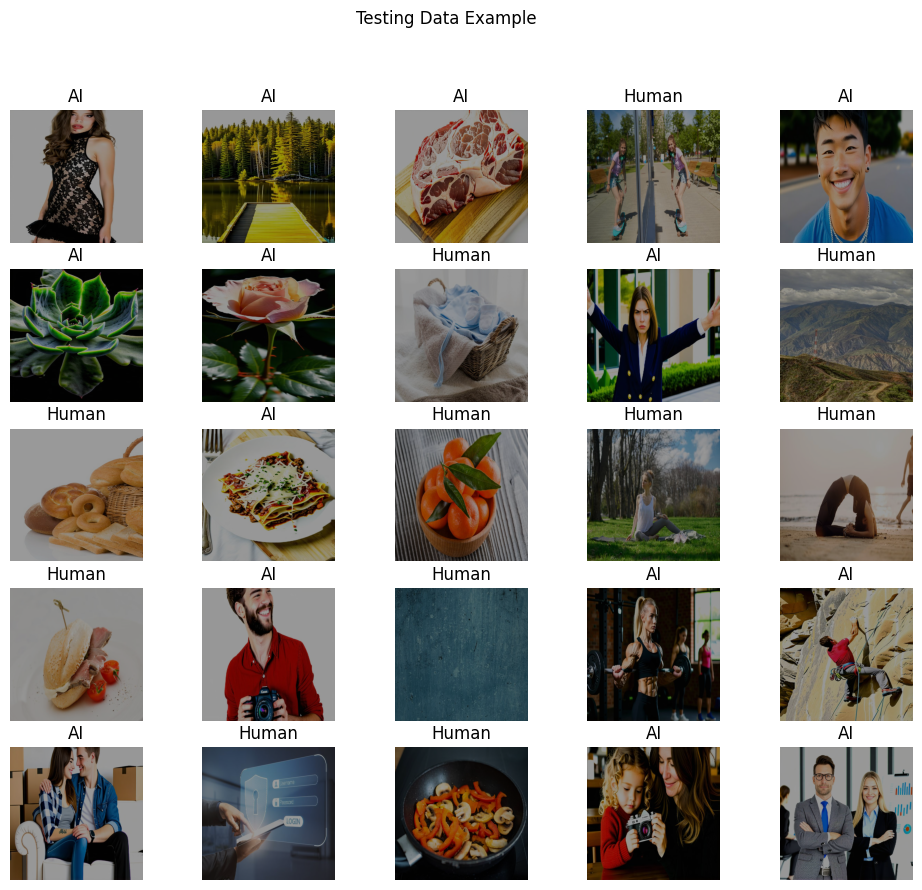

In [14]:
show_images(test_generator, 'Testing')

# ResNet50V2 Model

In [15]:
resnet50v2_path = './Model/ResNet50V2-AIvsHumanGenImages.keras' # ganti save path

if os.path.exists(resnet50v2_path):
    resnet50_model = keras.models.load_model(resnet50v2_path, compile=True)
    resnet50_model.trainable = False
else:
    resnet50_base_model = ResNet50V2(
        input_shape=(512, 512, 3),
        include_top=False,
        weights='imagenet'
    )
    resnet50_base_model.trainable = False

    inputs = keras.Input(shape=(512, 512, 3))
    x = resnet50_base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    resnet50_model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='ResNet50V2-AIvsHumanGenImages'
    )

    resnet50_model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

resnet50_model.summary()

Model: "ResNet50V2-AIvsHumanGenImages"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 resnet50v2 (Functional)     (None, 16, 16, 2048)      23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 32)                65568     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                     

In [16]:
resnet50v2_history_path = './Model/ResNet50V2-AIvsHumanGenImages-Logs.csv' # ganti save path

if os.path.exists(resnet50v2_history_path):
    resnet50v2_history = pd.read_csv(resnet50v2_history_path)
else:
    steps_per_epoch = len(train_generator)
    validation_steps = len(valid_generator)
    resnet50_model_history = resnet50_model.fit(
        train_generator,
        epochs=50,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_generator,
        validation_steps=validation_steps,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
            keras.callbacks.ModelCheckpoint('ResNet50V2-AIvsHumanGenImages.keras', save_best_only=True),
            keras.callbacks.CSVLogger('ResNet50V2-AIvsHumanGenImages-Logs.csv', append=True),
            keras.callbacks.TerminateOnNaN()
        ]
    )
    resnet50v2_history = pd.DataFrame(resnet50_model_history.history)
    resnet50v2_history.to_csv('ResNet50V2-AIvsHumanGenImages-Logs.csv', index=False)


Epoch 1/50
1999/1999 [==============================] - 706s 350ms/step - loss: 0.1687 - accuracy: 0.9334 - precision: 0.9327 - recall: 0.9341 - val_loss: 0.1078 - val_accuracy: 0.9600 - val_precision: 0.9552 - val_recall: 0.9652
Epoch 2/50
1999/1999 [==============================] - 638s 319ms/step - loss: 0.1177 - accuracy: 0.9544 - precision: 0.9535 - recall: 0.9553 - val_loss: 0.0962 - val_accuracy: 0.9612 - val_precision: 0.9675 - val_recall: 0.9545
Epoch 3/50
1999/1999 [==============================] - 612s 306ms/step - loss: 0.1024 - accuracy: 0.9605 - precision: 0.9599 - recall: 0.9612 - val_loss: 0.0949 - val_accuracy: 0.9602 - val_precision: 0.9740 - val_recall: 0.9457
Epoch 4/50
1999/1999 [==============================] - 582s 291ms/step - loss: 0.0910 - accuracy: 0.9652 - precision: 0.9645 - recall: 0.9659 - val_loss: 0.0911 - val_accuracy: 0.9666 - val_precision: 0.9573 - val_recall: 0.9767
Epoch 5/50
1999/1999 [==============================] - 570s 285ms/step - loss: 

In [17]:
test_loss, test_accuracy, *_ = resnet50_model.evaluate(test_generator)
print(f"Test Data -> Accuracy: {test_accuracy:.2%} | Loss: {test_loss:.4f}")

250/250 [==============================] - 75s 299ms/step - loss: 0.0864 - accuracy: 0.9689 - precision: 0.9690 - recall: 0.9687
Test Data -> Accuracy: 96.89% | Loss: 0.0864


In [18]:
print("Manually saving the final model state...")
resnet50_model.save('ResNet50V2-AIvsHumanGenImages-Final.keras')
print("Model saved.")

Manually saving the final model state...
Model saved.


# MobileNetV2 Model

In [19]:
mobilenetv2_path = './Model/MobileNetV2-AIvsHumanGenImages.keras'

if os.path.exists(mobilenetv2_path):
    mobilenet_model  = keras.models.load_model(mobilenetv2_path, compile=True)
    mobilenet_model.trainable = False
else:
    mobilenet_base_model = MobileNetV2(
        input_shape=(512, 512, 3),
        include_top=False,
        weights='imagenet'
    )

    mobilenet_base_model.trainable = False

    inputs = keras.Input(shape=(512, 512, 3))
    x = mobilenet_base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)


    mobilenet_model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='MobileNetV2-AIvsHumanGenImages'
    )

    mobilenet_model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

mobilenet_model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "MobileNetV2-AIvsHumanGenImages"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 16, 16, 1280)     2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 32)                40992     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                       

In [20]:
mobilenetv2_history_path  = './Model/MobileNetV2-AIvsHumanGenImages-Logs.csv'

if os.path.exists(mobilenetv2_history_path):
    mobilenet_model_history = pd.read_csv(mobilenetv2_history_path)
else:
    steps_per_epoch = len(train_generator)
    validation_steps = len(valid_generator)
    mobilenet_model_history = mobilenet_model.fit(
        train_generator,
        epochs=50,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_generator,
        validation_steps=validation_steps,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
            keras.callbacks.ModelCheckpoint('MobileNetV2-AIvsHumanGenImages.keras', save_best_only=True),
            keras.callbacks.CSVLogger('MobileNetV2-AIvsHumanGenImages-Logs.csv', append=True),
            keras.callbacks.TerminateOnNaN()
        ]
    )
    mobilenetv2_history  = pd.DataFrame(mobilenet_model_history.history)
    mobilenetv2_history.to_csv('MobileNetV2-AIvsHumanGenImages-Logs.csv', index=False)


Epoch 1/50
1999/1999 [==============================] - 519s 258ms/step - loss: 0.1841 - accuracy: 0.9273 - precision: 0.9278 - recall: 0.9267 - val_loss: 0.1467 - val_accuracy: 0.9391 - val_precision: 0.9650 - val_recall: 0.9112
Epoch 2/50
1999/1999 [==============================] - 513s 256ms/step - loss: 0.1348 - accuracy: 0.9480 - precision: 0.9491 - recall: 0.9467 - val_loss: 0.1258 - val_accuracy: 0.9500 - val_precision: 0.9646 - val_recall: 0.9342
Epoch 3/50
1999/1999 [==============================] - 511s 255ms/step - loss: 0.1218 - accuracy: 0.9525 - precision: 0.9549 - recall: 0.9499 - val_loss: 0.1152 - val_accuracy: 0.9541 - val_precision: 0.9502 - val_recall: 0.9585
Epoch 4/50
1999/1999 [==============================] - 515s 258ms/step - loss: 0.1152 - accuracy: 0.9552 - precision: 0.9570 - recall: 0.9532 - val_loss: 0.1121 - val_accuracy: 0.9570 - val_precision: 0.9516 - val_recall: 0.9630
Epoch 5/50
1999/1999 [==============================] - 518s 259ms/step - loss: 

In [21]:
test_loss, test_accuracy, *_ = mobilenet_model.evaluate(test_generator)
print(f"Test Data -> Accuracy: {test_accuracy:.2%} | Loss: {test_loss:.4f}")

250/250 [==============================] - 57s 228ms/step - loss: 0.1007 - accuracy: 0.9604 - precision: 0.9552 - recall: 0.9660
Test Data -> Accuracy: 96.04% | Loss: 0.1007


In [22]:
print("Manually saving the final model state...")
mobilenet_model.save('MobileNetV2-AIvsHumanGenImages-Final.keras')
print("Model saved.")

Manually saving the final model state...
Model saved.


# DenseNet121 Model

In [23]:
densenet121_path = './Model/DenseNet121-AIvsHumanGenImages.keras'

if os.path.exists(densenet121_path):
    densenet_model = keras.models.load_model(densenet121_path, compile=True)
    densenet_model.trainable = False
else:
    densenet_base_model = DenseNet121(
        input_shape=(512, 512, 3),
        include_top=False,
        weights='imagenet'
    )
    densenet_base_model.trainable = False

    inputs = keras.Input(shape=(512, 512, 3))
    x = densenet_base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    densenet_model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='DenseNet121-AIvsHumanGenImages'
    )

    densenet_model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

densenet_model.summary()

29084464/29084464 [==============================] - 2s 0us/step
Model: "DenseNet121-AIvsHumanGenImages"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 16, 16, 1024)      7037504   
                                                                 
 global_average_pooling2d_2   (None, 1024)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 32)                32800     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1

In [24]:
densenet121_history_path = './Model/DenseNet121-AIvsHumanGenImages-Logs.csv'

if os.path.exists(densenet121_history_path):
    densenet121_history = pd.read_csv(densenet121_history_path)
else:
    steps_per_epoch = len(train_generator)
    validation_steps = len(valid_generator)
    densenet_model_history = densenet_model.fit(
        train_generator,
        epochs=50,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_generator,
        validation_steps=validation_steps,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
            keras.callbacks.ModelCheckpoint('DenseNet121-AIvsHumanGenImages.keras', save_best_only=True),
            keras.callbacks.CSVLogger('DenseNet121-AIvsHumanGenImages-Logs.csv', append=True),
            keras.callbacks.TerminateOnNaN()
        ]
    )
    densenet121_history = pd.DataFrame(densenet_model_history.history)
    densenet121_history.to_csv('DenseNet121-AIvsHumanGenImages-Logs.csv', index=False)

Epoch 1/50
1999/1999 [==============================] - 699s 348ms/step - loss: 0.2165 - accuracy: 0.9127 - precision: 0.9141 - recall: 0.9110 - val_loss: 0.1348 - val_accuracy: 0.9465 - val_precision: 0.9369 - val_recall: 0.9575
Epoch 2/50
1999/1999 [==============================] - 694s 347ms/step - loss: 0.1495 - accuracy: 0.9411 - precision: 0.9409 - recall: 0.9412 - val_loss: 0.1343 - val_accuracy: 0.9460 - val_precision: 0.9249 - val_recall: 0.9707
Epoch 3/50
1999/1999 [==============================] - 694s 347ms/step - loss: 0.1368 - accuracy: 0.9470 - precision: 0.9445 - recall: 0.9497 - val_loss: 0.1256 - val_accuracy: 0.9502 - val_precision: 0.9339 - val_recall: 0.9690
Epoch 4/50
1999/1999 [==============================] - 701s 350ms/step - loss: 0.1292 - accuracy: 0.9497 - precision: 0.9488 - recall: 0.9508 - val_loss: 0.1216 - val_accuracy: 0.9510 - val_precision: 0.9345 - val_recall: 0.9700
Epoch 5/50
1999/1999 [==============================] - 710s 355ms/step - loss: 

In [25]:
test_loss, test_accuracy, *_ = densenet_model.evaluate(test_generator)
print(f"Test Data -> Accuracy: {test_accuracy:.2%} | Loss: {test_loss:.4f}")

250/250 [==============================] - 89s 356ms/step - loss: 0.0969 - accuracy: 0.9655 - precision: 0.9673 - recall: 0.9635
Test Data -> Accuracy: 96.55% | Loss: 0.0969


In [26]:
print("Manually saving the final model state...")
densenet_model.save("DenseNet121-AIvsHumanGenImages-Final.keras")
print("Model saved.")

Manually saving the final model state...
Model saved.


# Model Comparison

Successfully load ResNet50V2
Successfully load MobileNetV2
Successfully load DenseNet121

Comparison plot has been save as 'model_comparison_plots.png'


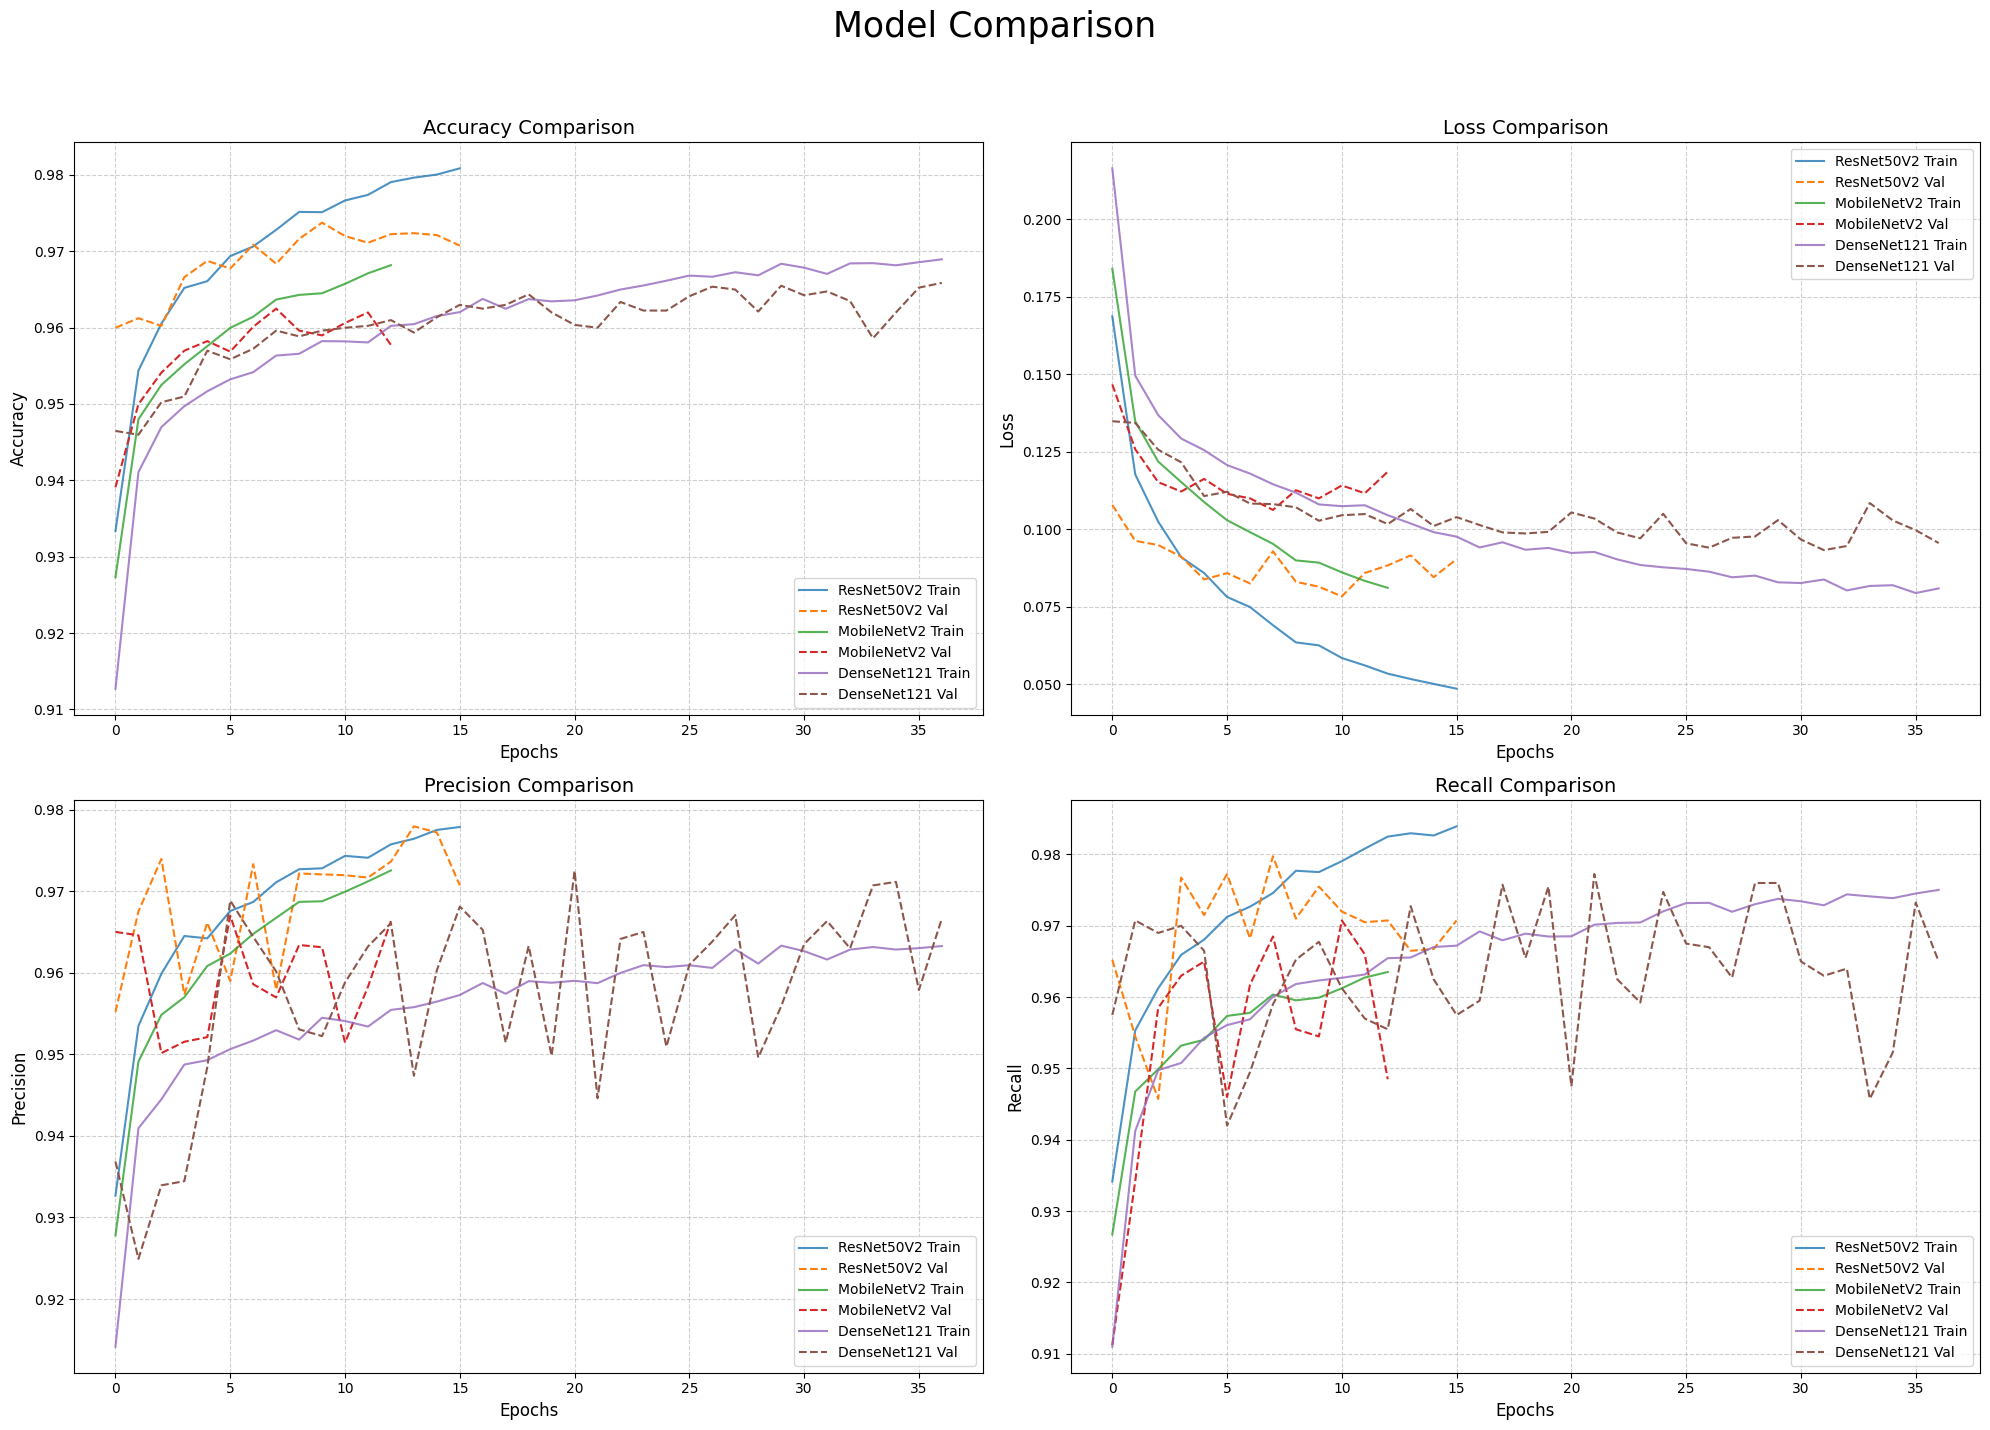

In [29]:
resnet_log_path = 'ResNet50V2-AIvsHumanGenImages-Logs.csv'
mobilenet_log_path = 'MobileNetV2-AIvsHumanGenImages-Logs.csv'
densenet_log_path = 'DenseNet121-AIvsHumanGenImages-Logs.csv'

history_files = {
    "ResNet50V2": resnet_log_path,
    "MobileNetV2": mobilenet_log_path,
    "DenseNet121": densenet_log_path
}

histories = {}
for model_name, path in history_files.items():
    if os.path.exists(path):
        histories[model_name] = pd.read_csv(path)
        print(f"Successfully load {model_name}")
    else:
        print(f"Log does not found in '{path}'")

if not histories:
    print("No log history.")
else:
    fig, axs = plt.subplots(2, 2, figsize=(20, 15))
    fig.suptitle('Model Comparison', fontsize=25)

    metrics = {
        'Accuracy': ('accuracy', 'val_accuracy'),
        'Loss': ('loss', 'val_loss'),
        'Precision': ('precision', 'val_precision'),
        'Recall': ('recall', 'val_recall')
    }

    plot_coords = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for (metric_name, (train_metric, val_metric)), ax_coords in zip(metrics.items(), plot_coords):
        ax = axs[ax_coords]

        for model_name, history_df in histories.items():
            if train_metric in history_df and val_metric in history_df:
                ax.plot(history_df[train_metric], label=f'{model_name} Train', alpha=0.8)
                ax.plot(history_df[val_metric], label=f'{model_name} Val', linestyle='--')

        ax.set_title(f'{metric_name} Comparison', fontsize=14)
        ax.set_xlabel('Epochs', fontsize=12)
        ax.set_ylabel(metric_name, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('model_comparison_plots.png')
    print("\nComparison plot has been save as 'model_comparison_plots.png'")

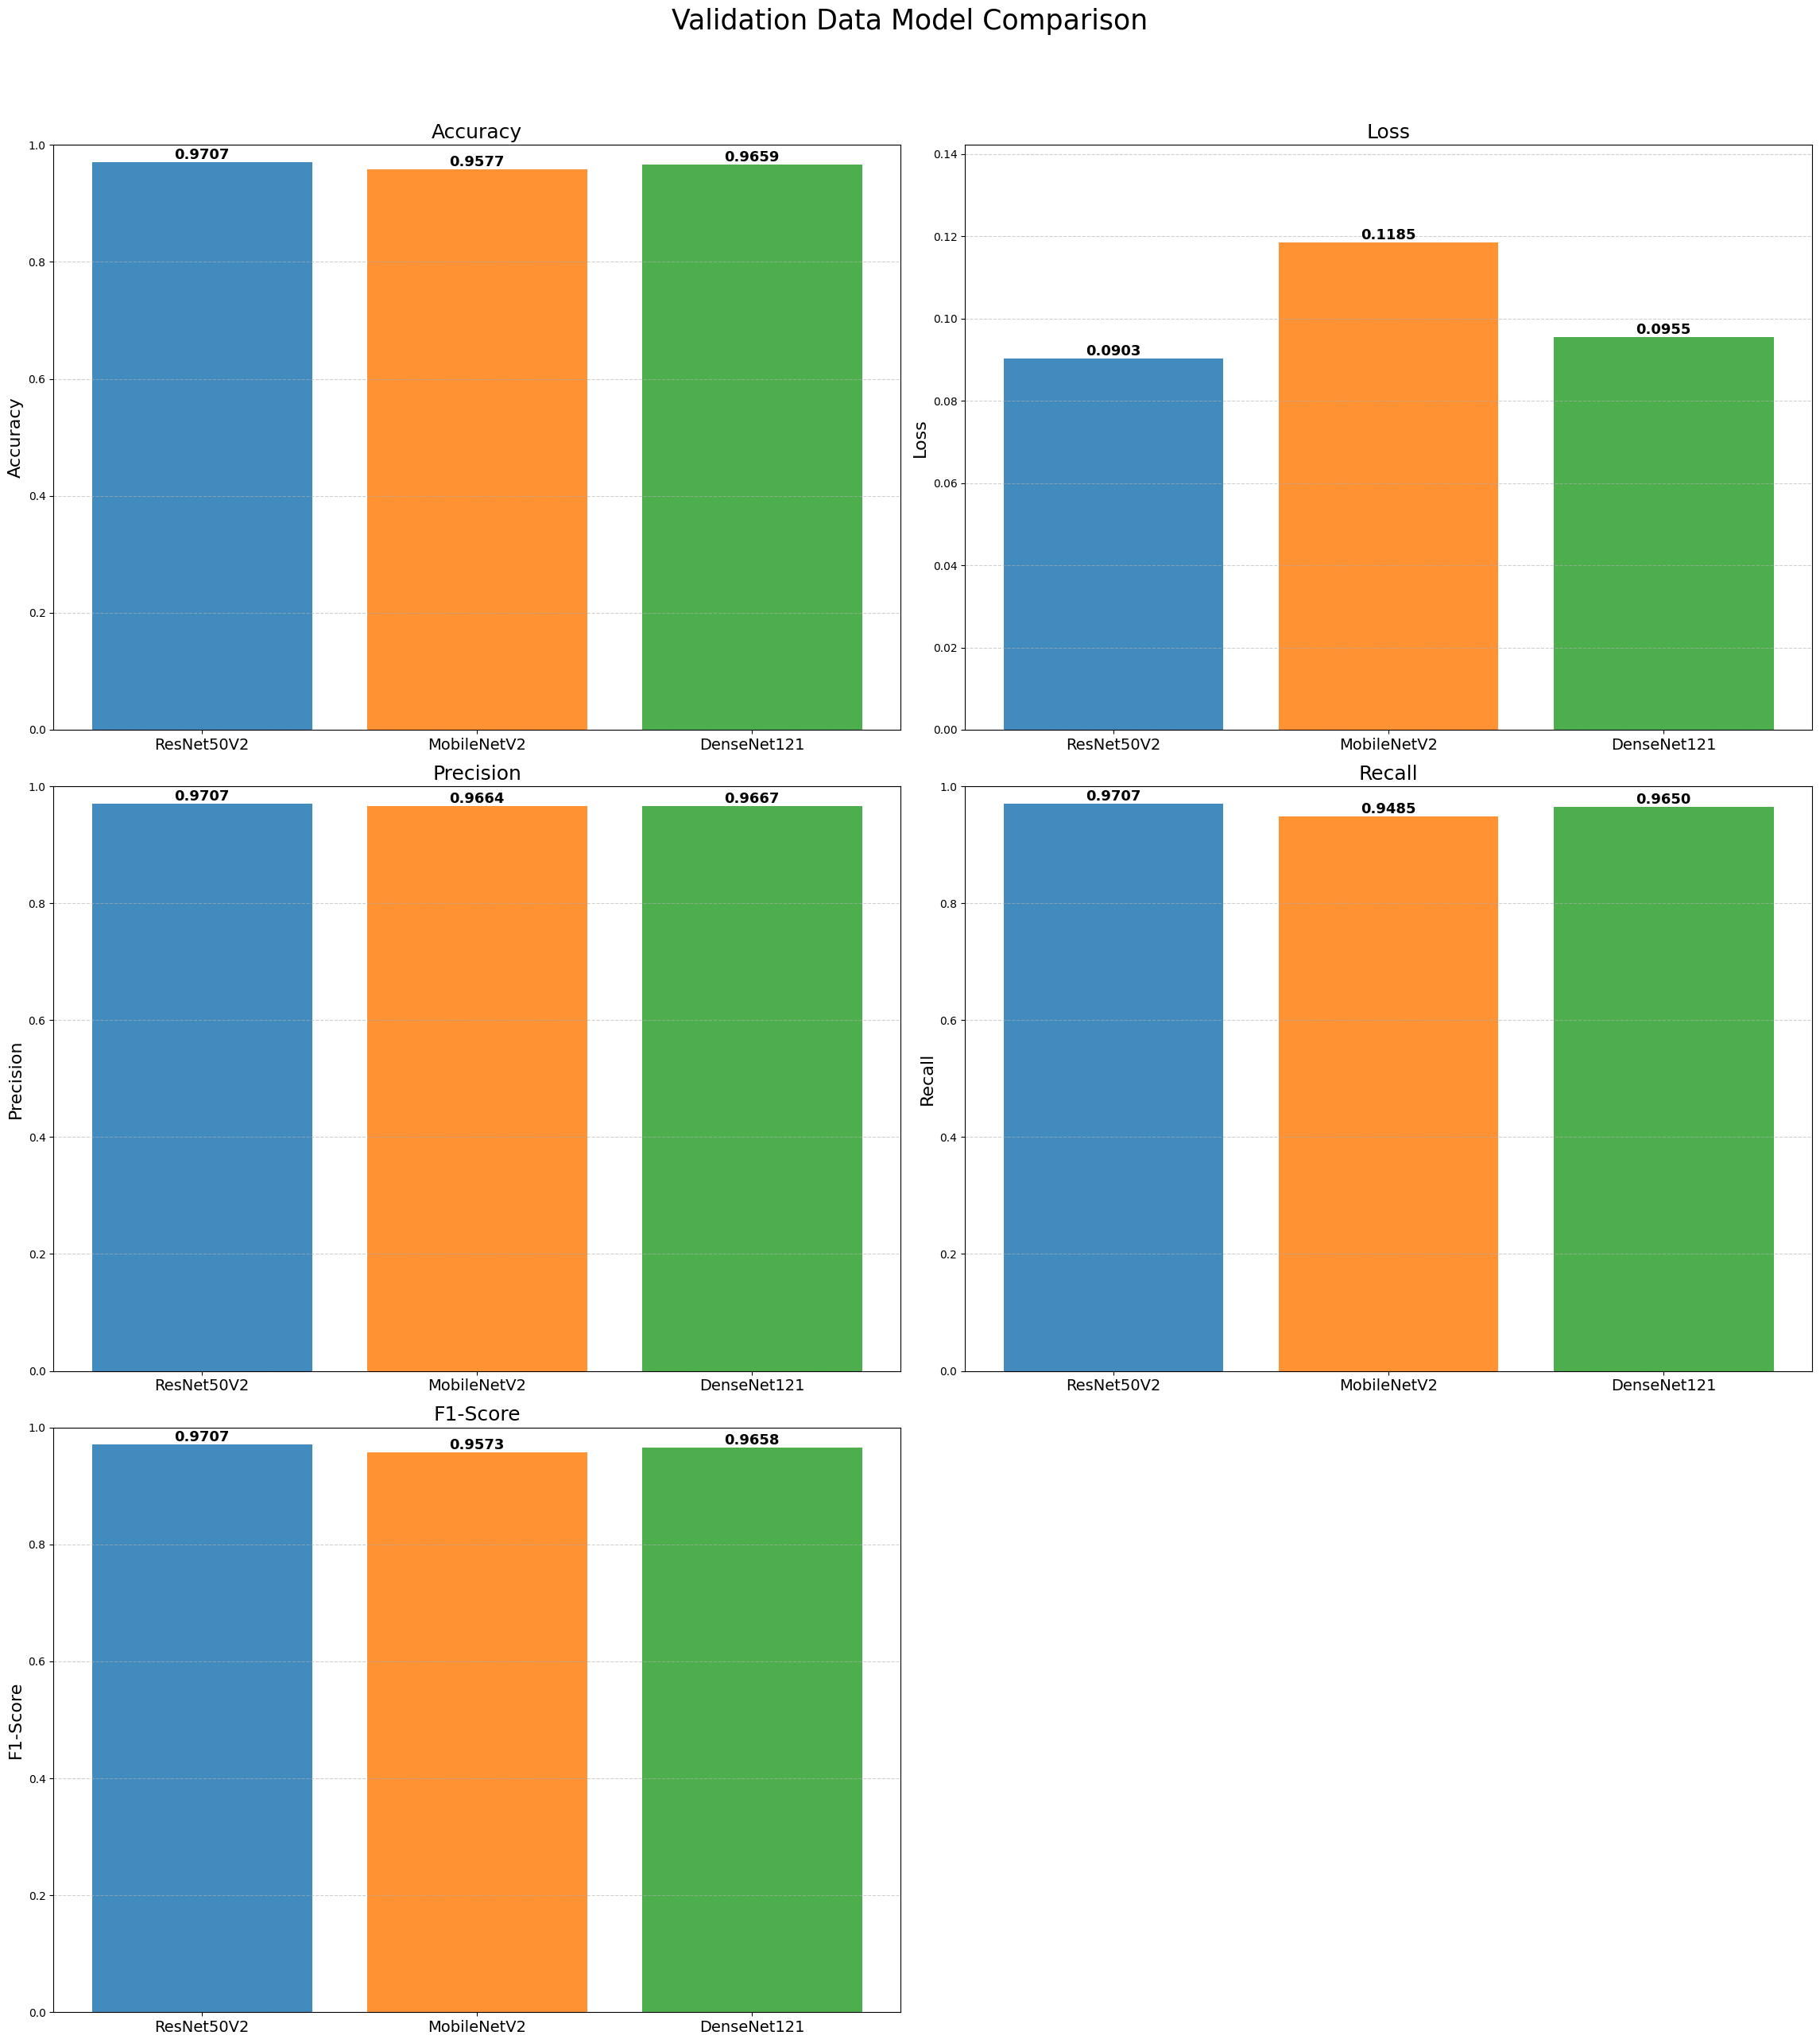

In [30]:
final_scores = {}

for model_name, history_df in histories.items():
    precision = history_df['val_precision'].iloc[-1]
    recall = history_df['val_recall'].iloc[-1]
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    final_scores[model_name] = {
        "Accuracy": history_df['val_accuracy'].iloc[-1],
        "Loss": history_df['val_loss'].iloc[-1],
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

metrics = ["Accuracy", "Loss", "Precision", "Recall", "F1-Score"]

colors = plt.cm.tab10.colors
model_names = list(final_scores.keys())
model_colors = {model: colors[i % len(colors)] for i, model in enumerate(model_names)}

fig, axs = plt.subplots(3, 2, figsize=(23, 27))
fig.suptitle('Validation Data Model Comparison', fontsize=25)

axs = axs.flatten()
plot_coords = range(len(metrics))

for metric, idx in zip(metrics, plot_coords):
    ax = axs[idx]
    values = [final_scores[m][metric] for m in final_scores]
    bars = ax.bar(model_names, values, color=[model_colors[m] for m in model_names], alpha=0.85)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

    ax.set_title(metric, fontsize=18)
    ax.set_ylabel(metric, fontsize=16)
    ax.tick_params(axis='x', labelsize=14, labelrotation=0)
    ax.set_ylim(0, 1 if metric not in ["Loss"] else max(values) * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

for j in range(len(metrics), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_comparison_barplots.png')
plt.show()